In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import MinMaxScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,event_OS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,114.312329,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,111.846575,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,49.479452,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,66.739726,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,42.805479,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,42.739726,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,42.312329,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,42.246575,0


In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D1['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D1 in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D1 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# Set lower, upper time point and gbsg_times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
gbsg_times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 14)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
gbsg_times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 16)

# Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
scaler = MinMaxScaler()  
X_std = scaler.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [19]:
X_std

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG
0,0.365347,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.0,0.435155,0.074159,0.044798
1,0.373041,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.213981,0.0,0.089331,0.008512,0.001900
2,0.487409,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.320284,1.0,0.191823,0.142839,0.043358
3,0.786304,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.292806,0.0,0.009957,0.016710,0.001102
4,0.713276,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.413832,0.0,0.102437,0.029551,0.006835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.523573,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.000000,0.0,0.245047,0.029363,0.012323
135,0.736989,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.000000,1.0,0.167389,0.189529,0.053209
136,0.448587,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.308411,0.0,0.413145,0.057805,0.033988
137,0.657597,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.558497,1.0,0.179660,0.121309,0.037000


# Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

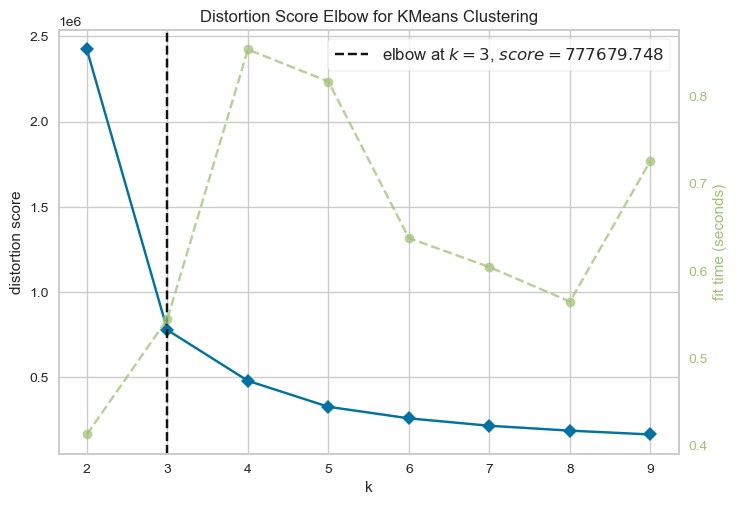

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [21]:
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(3):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=3)

0
Most correlated column: female
Correlation coefficient: 0.17850067771869405


1
Most correlated column: hpv_related
Correlation coefficient: 0.2460640183505367


2
Most correlated column: uicc8_III-IV
Correlation coefficient: 0.25148576790741356




In [22]:
selected_features

['female', 'hpv_related', 'uicc8_III-IV']

In [23]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Standardization

In [24]:
"""
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = MinMaxScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)
""" 
# Change the order of the X_new_std 
X_new_std = X_new

"\n# Standardize X_new, the new data with the selected features only \ncategorical_columns = ['female', \n                        'cavum_oris',\n                        'oropharynx',\n                        'hypopharynx',\n                        'larynx',\n                        'histgrade_high',\n                        'hpv_related',\n                        'charlson',\n                        'uicc8_III-IV']\n\n# Set the columns_to_drop which are categorical \ncolumns_to_drop = [col for col in X_new.columns if col in categorical_columns]\n\n# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric\nX_new_categoric = X_new[columns_to_drop]\nX_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)\n\n# Do the standardization for the numeric part \nscaler = MinMaxScaler() \nX_new_numeric_columns = X_new_numeric.columns\nX_new_numeric_index = X_new_numeric.index \nX_new_numeric_std = scaler.fit_transform(X_new_numeric)\nX_new_numeric_std 

In [25]:
""" 
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]
""" 
MAASTRO_new_std = MAASTRO_new

' \n# Standardize X_MAASTRO \n# Set the columns_to_drop which are categorical \ncolumns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]\n\n# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric\nMAASTRO_new_categoric = MAASTRO_new[columns_to_drop]\nMAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)\n\n# Do the standardization for the numeric part \nMAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns\nMAASTRO_new_numeric_index = MAASTRO_new_numeric.index \nMAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)\nMAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,\n                                 columns=MAASTRO_new_numeric_columns, \n                                 index=MAASTRO_new_numeric_index)\nMAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)\n\n# Change the order of the X_new_std \nMAASTRO_new_std = MAASTRO_new_std[MAASTRO_n

In [26]:
X_new

,female,hpv_related,uicc8_III-IV
0,1,0.0,0.0
1,0,0.0,0.0
2,0,0.0,1.0
3,0,0.0,0.0
4,0,0.0,0.0
...,...,...,...
134,0,1.0,0.0
135,0,1.0,1.0
136,0,1.0,0.0
137,0,1.0,1.0


In [27]:
X_new_std

,female,hpv_related,uicc8_III-IV
0,1,0.0,0.0
1,0,0.0,0.0
2,0,0.0,1.0
3,0,0.0,0.0
4,0,0.0,0.0
...,...,...,...
134,0,1.0,0.0
135,0,1.0,1.0
136,0,1.0,0.0
137,0,1.0,1.0


In [28]:
MAASTRO_new

,female,hpv_related,uicc8_III-IV
0,0,1,0
1,0,0,1
2,0,0,1
3,1,0,1
4,0,1,0
...,...,...,...
94,1,0,1
95,0,0,1
96,0,1,1
97,0,1,0


In [29]:
MAASTRO_new_std

,female,hpv_related,uicc8_III-IV
0,0,1,0
1,0,0,1
2,0,0,1
3,1,0,1
4,0,1,0
...,...,...,...
94,1,0,1
95,0,0,1
96,0,1,1
97,0,1,0


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [30]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                gbsg_times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(gbsg_times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, gbsg_times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-19 17:23:54,272] A new study created in memory with name: no-name-0a0ab81a-a587-4b94-939f-2d3b479a2c4d


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7745098039215687
Fold 4 C-index: 0.810126582278481


[I 2024-04-19 17:23:55,329] A new study created in memory with name: no-name-fbf2f24e-78ef-4a21-b721-bf6fb43ba516


Fold 5 C-index: 0.6220657276995305
[I 2024-04-19 17:23:55,321] Trial 0 finished with value: 0.7304096868491801 and parameters: {}. Best is trial 0 with value: 0.7304096868491801.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7304096868491801], datetime_start=datetime.datetime(2024, 4, 19, 17, 23, 54, 629667), datetime_complete=datetime.datetime(2024, 4, 19, 17, 23, 55, 318691), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7304096868491801


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.15527174704078797
Fold 2 IBS: 0.2145630883611508
Fold 3 IBS: 0.17542102475964233
Fold 4 IBS: 0.15316340886531135
Fold 5 IBS: 0.23735466698463892
[I 2024-04-19 17:23:56,576] Trial 0 finished with value: 0.18715478720230627 and parameters: {}. Best is trial 0 with value: 0.18715478720230627.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.18715478720230627], datetime_start=datetime.datetime(2024, 4, 19, 17, 23, 55, 373924), datetime_complete=datetime.datetime(2024, 4, 19, 17, 23, 56, 575378), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.18715478720230627


In [31]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [32]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.73
train_ibs:  0.187


#### Test

In [33]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [34]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
gbsg_times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(gbsg_times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, gbsg_times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.555
IBS score: 0.231


In [35]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [36]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [37]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                gbsg_times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(gbsg_times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, gbsg_times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 17:23:57,123] A new study created in memory with name: no-name-5e31250a-a114-49a1-b4ae-64bad21e7828


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7745098039215687


[I 2024-04-19 17:23:57,757] A new study created in memory with name: no-name-802815fe-d52b-4b3d-9f4a-46ff96bc6cd6


Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6150234741784038
[I 2024-04-19 17:23:57,734] Trial 0 finished with value: 0.7268586529897133 and parameters: {}. Best is trial 0 with value: 0.7268586529897133.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7268586529897133], datetime_start=datetime.datetime(2024, 4, 19, 17, 23, 57, 154590), datetime_complete=datetime.datetime(2024, 4, 19, 17, 23, 57, 732088), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7268586529897133


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21397651777490725
Fold 2 IBS: 0.2215779141699564
Fold 3 IBS: 0.20453594224963634
Fold 4 IBS: 0.224738034459558
Fold 5 IBS: 0.2181243143679756
[I 2024-04-19 17:23:58,564] Trial 0 finished with value: 0.2165905446044067 and parameters: {}. Best is trial 0 with value: 0.2165905446044067.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2165905446044067], datetime_start=datetime.datetime(2024, 4, 19, 17, 23, 57, 785700), datetime_complete=datetime.datetime(2024, 4, 19, 17, 23, 58, 504854), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2165905446044067


In [38]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [39]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.727
train_ibs:  0.217


#### Test

In [40]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [41]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
gbsg_times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(gbsg_times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, gbsg_times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.593


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [42]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [43]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                gbsg_times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(gbsg_times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, gbsg_times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 17:23:59,214] A new study created in memory with name: no-name-94035b12-df92-43a3-bffa-206e84ac6d00


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7745098039215687
Fold 4 C-index: 0.810126582278481


[I 2024-04-19 17:24:00,968] A new study created in memory with name: no-name-d820d4bc-e6e4-4f78-b05c-b7e4e1c4b4cd


Fold 5 C-index: 0.6220657276995305
[I 2024-04-19 17:24:00,959] Trial 0 finished with value: 0.7304096868491801 and parameters: {}. Best is trial 0 with value: 0.7304096868491801.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7304096868491801], datetime_start=datetime.datetime(2024, 4, 19, 17, 23, 59, 244966), datetime_complete=datetime.datetime(2024, 4, 19, 17, 24, 0, 959372), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7304096868491801


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.15627889025303432
Fold 2 IBS: 0.21423081311279465
Fold 3 IBS: 0.17471813819191373
Fold 4 IBS: 0.1535136229635454
Fold 5 IBS: 0.236628120156054
[I 2024-04-19 17:24:03,331] Trial 0 finished with value: 0.18707391693546843 and parameters: {}. Best is trial 0 with value: 0.18707391693546843.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.18707391693546843], datetime_start=datetime.datetime(2024, 4, 19, 17, 24, 1, 194745), datetime_complete=datetime.datetime(2024, 4, 19, 17, 24, 3, 331010), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.18707391693546843


In [44]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [45]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.73
train_ibs:  0.187


#### Test

In [46]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [47]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
gbsg_times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(gbsg_times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, gbsg_times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.555


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.229


In [48]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [49]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                gbsg_times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(gbsg_times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, gbsg_times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 17:24:04,255] A new study created in memory with name: no-name-6607f267-d1e4-4563-bcbe-87a548837278


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7745098039215687
Fold 4 C-index: 0.810126582278481
Fold 5 C-index: 0.6220657276995305
[I 2024-04-19 17:24:05,630] Trial 0 finished with value: 0.7304096868491801 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.7304096868491801.
Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7745098039215687
Fold 4 C-index: 0.810126582278481
Fold 5 C-index: 0.6220657276995305
[I 2024-04-19 17:24:07,614] Trial 1 finished with value: 0.7304096868491801 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.7304096868491801.
Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7745098039215687
Fold 4 C-index: 0.810126582278481
Fold 5 C-index: 0.6220657276995305
[I 2024-04-19 17:24:09,112] Trial 2 finished with value: 0.7304096868491801 and parameters: {'l1_ratio': 0.22692876841884668}. Be

Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7745098039215687
Fold 4 C-index: 0.810126582278481
Fold 5 C-index: 0.6220657276995305
[I 2024-04-19 17:24:36,128] Trial 24 finished with value: 0.7304096868491801 and parameters: {'l1_ratio': 0.15433706302991543}. Best is trial 0 with value: 0.7304096868491801.
Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7745098039215687
Fold 4 C-index: 0.810126582278481
Fold 5 C-index: 0.6220657276995305
[I 2024-04-19 17:24:37,262] Trial 25 finished with value: 0.7304096868491801 and parameters: {'l1_ratio': 0.4626599986704694}. Best is trial 0 with value: 0.7304096868491801.
Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7745098039215687
Fold 4 C-index: 0.810126582278481
Fold 5 C-index: 0.6220657276995305
[I 2024-04-19 17:24:38,661] Trial 26 finished with value: 0.7304096868491801 and parameters: {'l1_ratio': 0.3312072877416866}. 

Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7745098039215687
Fold 4 C-index: 0.810126582278481
Fold 5 C-index: 0.6220657276995305
[I 2024-04-19 17:25:03,493] Trial 48 finished with value: 0.7304096868491801 and parameters: {'l1_ratio': 0.5675456270820948}. Best is trial 0 with value: 0.7304096868491801.
Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7745098039215687
Fold 4 C-index: 0.810126582278481
Fold 5 C-index: 0.6220657276995305
[I 2024-04-19 17:25:04,502] Trial 49 finished with value: 0.7304096868491801 and parameters: {'l1_ratio': 0.7153190338760974}. Best is trial 0 with value: 0.7304096868491801.
Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7745098039215687
Fold 4 C-index: 0.810126582278481
Fold 5 C-index: 0.6220657276995305
[I 2024-04-19 17:25:05,693] Trial 50 finished with value: 0.7304096868491801 and parameters: {'l1_ratio': 0.5027665121167861}. B

...

Fold 1 IBS: 0.15595608318212514
Fold 2 IBS: 0.21389624872403198
Fold 3 IBS: 0.17477124580275008
Fold 4 IBS: 0.15356697174826547
Fold 5 IBS: 0.23652678344224728
[I 2024-04-19 17:26:04,752] Trial 0 finished with value: 0.186943466579884 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.186943466579884.
Fold 1 IBS: 0.1554780481353277
Fold 2 IBS: 0.2133301337483304
Fold 3 IBS: 0.17479279092704772
Fold 4 IBS: 0.1536525810700879
Fold 5 IBS: 0.2364276624479044
[I 2024-04-19 17:26:06,013] Trial 1 finished with value: 0.18673624326573962 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.18673624326573962.
Fold 1 IBS: 0.15538832123656182
Fold 2 IBS: 0.2133216511176963
Fold 3 IBS: 0.17484459200919836
Fold 4 IBS: 0.15362563844449262
Fold 5 IBS: 0.23637844925379783
[I 2024-04-19 17:26:07,350] Trial 2 finished with value: 0.1867117304123494 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.1867117304123494.
F

Fold 2 IBS: 0.21304173457629247
Fold 3 IBS: 0.17489200514603565
Fold 4 IBS: 0.22206582514781645
Fold 5 IBS: 0.2362731151298581
[I 2024-04-19 17:26:39,301] Trial 25 finished with value: 0.21172835359572426 and parameters: {'l1_ratio': 0.03981317955666948}. Best is trial 12 with value: 0.18661857632537274.
Fold 1 IBS: 0.15533764177862228
Fold 2 IBS: 0.2132779337059402
Fold 3 IBS: 0.1748595103824477
Fold 4 IBS: 0.15367173613015334
Fold 5 IBS: 0.23637010193289118
[I 2024-04-19 17:26:40,849] Trial 26 finished with value: 0.18670338478601095 and parameters: {'l1_ratio': 0.18783928730207888}. Best is trial 12 with value: 0.18661857632537274.
Fold 1 IBS: 0.155857977286517
Fold 2 IBS: 0.2137213062235175
Fold 3 IBS: 0.17476201219484103
Fold 4 IBS: 0.15359677789140358
Fold 5 IBS: 0.23651988827692766
[I 2024-04-19 17:26:42,088] Trial 27 finished with value: 0.18689159237464134 and parameters: {'l1_ratio': 0.58416616744615}. Best is trial 12 with value: 0.18661857632537274.
Fold 1 IBS: 0.1552142333

Fold 2 IBS: 0.21300332831022062
Fold 3 IBS: 0.17487970199602343
Fold 4 IBS: 0.22213298273338675
Fold 5 IBS: 0.23625993045080887
[I 2024-04-19 17:27:18,491] Trial 50 finished with value: 0.2117370780832438 and parameters: {'l1_ratio': 0.038779323250356386}. Best is trial 12 with value: 0.18661857632537274.
Fold 1 IBS: 0.15520693439944586
Fold 2 IBS: 0.21313222860401673
Fold 3 IBS: 0.17488647568314838
Fold 4 IBS: 0.15368271929721947
Fold 5 IBS: 0.23631065889783723
[I 2024-04-19 17:27:20,324] Trial 51 finished with value: 0.18664380337633352 and parameters: {'l1_ratio': 0.08640058638065554}. Best is trial 12 with value: 0.18661857632537274.
Fold 1 IBS: 0.15521586797952905
Fold 2 IBS: 0.21311203929231823
Fold 3 IBS: 0.17487359150224424
Fold 4 IBS: 0.1536454621231253
Fold 5 IBS: 0.23629130044696806
[I 2024-04-19 17:27:22,158] Trial 52 finished with value: 0.18662765226883696 and parameters: {'l1_ratio': 0.09291286560199638}. Best is trial 12 with value: 0.18661857632537274.
Fold 1 IBS: 0.21

Fold 1 IBS: 0.15535453505577024
Fold 2 IBS: 0.21321741535728692
Fold 3 IBS: 0.17482679796432246
Fold 4 IBS: 0.1536528534327118
Fold 5 IBS: 0.2363035490370264
[I 2024-04-19 17:27:54,958] Trial 75 finished with value: 0.18667103016942357 and parameters: {'l1_ratio': 0.19496418304850166}. Best is trial 67 with value: 0.1866133059305816.
Fold 1 IBS: 0.15551767751372125
Fold 2 IBS: 0.21336876865346724
Fold 3 IBS: 0.17483573574674882
Fold 4 IBS: 0.15365158969813866
Fold 5 IBS: 0.23643678972514995
[I 2024-04-19 17:27:56,182] Trial 76 finished with value: 0.18676211226744516 and parameters: {'l1_ratio': 0.31593264873255283}. Best is trial 67 with value: 0.1866133059305816.
Fold 1 IBS: 0.15522135263290326
Fold 2 IBS: 0.21306109025248518
Fold 3 IBS: 0.17485030068239732
Fold 4 IBS: 0.15366686165722776
Fold 5 IBS: 0.23635629795610602
[I 2024-04-19 17:27:57,738] Trial 77 finished with value: 0.18663118063622391 and parameters: {'l1_ratio': 0.09783138914205564}. Best is trial 67 with value: 0.186613

Fold 5 IBS: 0.23627048567778694
[I 2024-04-19 17:28:26,296] Trial 99 finished with value: 0.18660512542489444 and parameters: {'l1_ratio': 0.06816782511178934}. Best is trial 84 with value: 0.18660197154679128.


* Best trial for IBS: 
 FrozenTrial(number=84, state=TrialState.COMPLETE, values=[0.18660197154679128], datetime_start=datetime.datetime(2024, 4, 19, 17, 28, 5, 655902), datetime_complete=datetime.datetime(2024, 4, 19, 17, 28, 7, 413914), params={'l1_ratio': 0.06201384523056162}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=84, value=None)


* Best Score for IBS: 
 0.18660197154679128


In [50]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [51]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.73
train_ibs:  0.187


#### Test

In [52]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [53]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
gbsg_times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(gbsg_times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, gbsg_times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.6964995386793018)

test_cindex : 0.555


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.06201384523056162)

test_ibs:  0.229


In [54]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [55]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                gbsg_times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(gbsg_times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, gbsg_times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-19 17:28:27,115] A new study created in memory with name: no-name-6a211c43-73f5-4955-873a-8448067bc575


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6197183098591549
[I 2024-04-19 17:28:39,070] Trial 0 finished with value: 0.7287780122827263 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.7287780122827263.
Fold 1 C-index: 0.7748917748917749
Fold 2 C-index: 0.6785714285714286
Fold 3 C-index: 0.7745098039215687
Fold 4 C-index: 0.7974683544303798
Fold 5 C-index: 0.6220657276995305
[I 2024-04-19 17:28:47,448] Trial 1 finished with value: 0.7295014179029364 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 

Fold 5 C-index: 0.6103286384976526
[I 2024-04-19 17:30:40,039] Trial 15 finished with value: 0.7349357922961401 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 16, 'min_samples_leaf': 8, 'max_depth': 1, 'n_estimators': 383, 'oob_score': True, 'max_samples': 0.4747428535255964, 'max_features': None, 'min_weight_fraction_leaf': 0.19147439464820804, 'warm_start': True}. Best is trial 6 with value: 0.7360457641945901.
Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-19 17:30:49,612] Trial 16 finished with value: 0.7349357922961401 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 2, 'min_samples_leaf': 15, 'max_depth': 16, 'n_estimators': 498, 'oob_score': True, 'max_samples': 0.8344337766213217, 'max_features': None, 'min_weight_fraction_leaf': 0.3757514544542036, 'warm_start': True}. Best is trial 6 with value: 0.7360457641945901.


Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 17:32:32,838] Trial 30 finished with value: 0.5 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 13, 'min_samples_leaf': 18, 'max_depth': 18, 'n_estimators': 312, 'oob_score': True, 'max_samples': 0.610992839245566, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.4101391151116046, 'warm_start': True}. Best is trial 17 with value: 0.7404061854486199.
Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.7843137254901961
Fold 4 C-index: 0.810126582278481
Fold 5 C-index: 0.6220657276995305
[I 2024-04-19 17:32:40,200] Trial 31 finished with value: 0.7404061854486199 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 18, 'min_samples_leaf': 11, 'max_depth': 20, 'n_estimators': 408, 'oob_score': True, 'max_samples': 0.5131796235716322, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.18724061795221464, 'warm_start': 

...

Fold 4 IBS: 0.15511687049432457
Fold 5 IBS: 0.2365710525860896
[I 2024-04-19 18:59:46,969] Trial 31 finished with value: 0.18661529424056186 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 19, 'min_samples_leaf': 5, 'max_depth': 17, 'n_estimators': 474, 'oob_score': True, 'max_samples': 0.5841498292495204, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.027382421503448717}. Best is trial 22 with value: 0.18366386183468064.
Fold 1 IBS: 0.16384524633685182
Fold 2 IBS: 0.2004519314484572
Fold 3 IBS: 0.1720511951801352
Fold 4 IBS: 0.1692962883010919
Fold 5 IBS: 0.2224521441806214
[I 2024-04-19 19:00:05,067] Trial 32 finished with value: 0.1856193610894315 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 17, 'min_samples_leaf': 6, 'max_depth': 14, 'n_estimators': 461, 'oob_score': True, 'max_samples': 0.4958032147096568, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.10884764482583958}. Best is trial 22 with value: 0.18366386183468064.
Fold 1 IBS: 0.16395

Fold 1 IBS: 0.15781910873624638
Fold 2 IBS: 0.19954852987904376
Fold 3 IBS: 0.17169644979286702
Fold 4 IBS: 0.16095920353838353
Fold 5 IBS: 0.2287444339099039
[I 2024-04-19 19:04:19,185] Trial 47 finished with value: 0.18375354517128892 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 17, 'min_samples_leaf': 11, 'max_depth': 20, 'n_estimators': 209, 'oob_score': True, 'max_samples': 0.8252659010917025, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.026106601110240463}. Best is trial 22 with value: 0.18366386183468064.
Fold 1 IBS: 0.15936989122545137
Fold 2 IBS: 0.19882917327970223
Fold 3 IBS: 0.17145107173116375
Fold 4 IBS: 0.16341683742499657
Fold 5 IBS: 0.22571177876477644
[I 2024-04-19 19:04:37,616] Trial 48 finished with value: 0.18375575048521806 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 17, 'min_samples_leaf': 12, 'max_depth': 20, 'n_estimators': 217, 'oob_score': True, 'max_samples': 0.7987060583531351, 'max_features': 'sqrt', 'min_weight_frac

Fold 5 IBS: 0.2307102488268817
[I 2024-04-19 19:07:22,166] Trial 62 finished with value: 0.18343541498750618 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 16, 'min_samples_leaf': 10, 'max_depth': 20, 'n_estimators': 164, 'oob_score': True, 'max_samples': 0.86927695886691, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.08530849945852438}. Best is trial 62 with value: 0.18343541498750618.
Fold 1 IBS: 0.16184361450060372
Fold 2 IBS: 0.20014864753397704
Fold 3 IBS: 0.17080691797831565
Fold 4 IBS: 0.16743289193594313
Fold 5 IBS: 0.22402842367268513
[I 2024-04-19 19:07:29,960] Trial 63 finished with value: 0.18485209912430495 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 16, 'min_samples_leaf': 11, 'max_depth': 20, 'n_estimators': 135, 'oob_score': True, 'max_samples': 0.8543575959021708, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.1968520257015482}. Best is trial 62 with value: 0.18343541498750618.
Fold 1 IBS: 0.15685660846303112
Fold 2 IBS: 0.19

Fold 1 IBS: 0.15732998641628596
Fold 2 IBS: 0.19988414989058292
Fold 3 IBS: 0.17176190561742677
Fold 4 IBS: 0.162558630997039
Fold 5 IBS: 0.22766651293540352
[I 2024-04-19 19:09:49,296] Trial 78 finished with value: 0.18384023717134765 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 14, 'min_samples_leaf': 8, 'max_depth': 14, 'n_estimators': 204, 'oob_score': True, 'max_samples': 0.9849629212600256, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.17090852383789573}. Best is trial 62 with value: 0.18343541498750618.
Fold 1 IBS: 0.16255873593748033
Fold 2 IBS: 0.19960444054390994
Fold 3 IBS: 0.1715621276832796
Fold 4 IBS: 0.16807101930885754
Fold 5 IBS: 0.22228747648543443
[I 2024-04-19 19:09:59,483] Trial 79 finished with value: 0.18481675999179237 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 10, 'min_samples_leaf': 15, 'max_depth': 16, 'n_estimators': 237, 'oob_score': True, 'max_samples': 0.8692176712964624, 'max_features': 'sqrt', 'min_weight_fraction

Fold 5 IBS: 0.23070086087081
[I 2024-04-19 19:11:54,895] Trial 93 finished with value: 0.1834511026865548 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 20, 'min_samples_leaf': 11, 'max_depth': 15, 'n_estimators': 176, 'oob_score': False, 'max_samples': 0.9566535426675847, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.031479506315376805}. Best is trial 62 with value: 0.18343541498750618.
Fold 1 IBS: 0.1588410987452949
Fold 2 IBS: 0.19858773380162711
Fold 3 IBS: 0.17111644947920845
Fold 4 IBS: 0.16287531365299848
Fold 5 IBS: 0.2271120618025012
[I 2024-04-19 19:12:01,232] Trial 94 finished with value: 0.18370653149632604 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 20, 'min_samples_leaf': 13, 'max_depth': 15, 'n_estimators': 180, 'oob_score': False, 'max_samples': 0.9550589481099377, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.03184823940198047}. Best is trial 62 with value: 0.18343541498750618.
Fold 1 IBS: 0.15882128385963692
Fold 2 IBS: 0.1

In [56]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [57]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.74
train_ibs:  0.183


#### Test

In [58]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [59]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
gbsg_times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(gbsg_times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, gbsg_times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=1, max_leaf_nodes=15,
                     max_samples=0.5061365602629481, min_samples_leaf=11,
                     min_samples_split=17,
                     min_weight_fraction_leaf=0.0508449952624246,
                     n_estimators=415, oob_score=True, random_state=123,
                     warm_start=True)

test_cindex:  0.555


RandomSurvivalForest(max_depth=15, max_leaf_nodes=20,
                     max_samples=0.954212919583756, min_samples_leaf=11,
                     min_samples_split=13,
                     min_weight_fraction_leaf=0.01418156270426759,
                     n_estimators=185, random_state=123)

test_ibs:  0.224


In [60]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [61]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                gbsg_times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(gbsg_times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, gbsg_times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 19:12:34,528] A new study created in memory with name: no-name-8eb37be9-8a21-4c2b-8e0a-464199e2d1a5


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7748917748917749
Fold 2 C-index: 0.6919642857142857
Fold 3 C-index: 0.7745098039215687
Fold 4 C-index: 0.7974683544303798
Fold 5 C-index: 0.6220657276995305
[I 2024-04-19 19:12:37,655] Trial 0 finished with value: 0.7321799893315079 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.7321799893315079.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 19:12:46,149] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-19 19:13:55,194] Trial 16 finished with value: 0.7349357922961401 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 20, 'min_samples_leaf': 20, 'max_depth': 9, 'n_estimators': 204, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.7141272518076552, 'min_weight_fraction_leaf': 0.1144909881867055}. Best is trial 11 with value: 0.7386204711629055.
Fold 1 C-index: 0.7705627705627706
Fold 2 C-index: 0.71875
Fold 3 C-index: 0.7843137254901961
Fold 4 C-index: 0.7974683544303798
Fold 5 C-index: 0.607981220657277
[I 2024-04-19 19:13:56,285] Trial 17 finished with value: 0.7358152142281247 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 5, 'n_estimators': 70, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', '

Fold 1 C-index: 0.7705627705627706
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.7843137254901961
Fold 4 C-index: 0.7974683544303798
Fold 5 C-index: 0.6126760563380281
[I 2024-04-19 19:14:34,916] Trial 31 finished with value: 0.7349684670785607 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 3, 'min_samples_leaf': 15, 'max_depth': 12, 'n_estimators': 362, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.926062514731145, 'min_weight_fraction_leaf': 0.22106107948025916}. Best is trial 20 with value: 0.7404061854486199.
Fold 1 C-index: 0.7705627705627706
Fold 2 C-index: 0.71875
Fold 3 C-index: 0.7843137254901961
Fold 4 C-index: 0.7974683544303798
Fold 5 C-index: 0.607981220657277
[I 2024-04-19 19:14:37,158] Trial 32 finished with value: 0.7358152142281247 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 6, 'min_samples_leaf': 14, 'max_depth': 17, 'n_estimators': 183, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt

...

Fold 1 IBS: 0.15702846184926098
Fold 2 IBS: 0.19947833695130524
Fold 3 IBS: 0.17150683007531903
Fold 4 IBS: 0.16090579565851826
Fold 5 IBS: 0.22900478878834182
[I 2024-04-19 19:21:28,064] Trial 30 finished with value: 0.18358484266454905 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 17, 'min_samples_leaf': 6, 'max_depth': 2, 'n_estimators': 101, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.6258729719979372, 'min_weight_fraction_leaf': 0.10126341132894365}. Best is trial 24 with value: 0.18321395018244657.
Fold 1 IBS: 0.15691760079786976
Fold 2 IBS: 0.19936751045648154
Fold 3 IBS: 0.17163092935318752
Fold 4 IBS: 0.16071395474409345
Fold 5 IBS: 0.22984106454353243
[I 2024-04-19 19:21:32,015] Trial 31 finished with value: 0.18369421197903293 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 17, 'min_samples_leaf': 6, 'max_depth': 2, 'n_estimators': 101, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.618351

Fold 1 IBS: 0.16600304630699322
Fold 2 IBS: 0.20554641131345885
Fold 3 IBS: 0.17420085708168143
Fold 4 IBS: 0.1688560393871206
Fold 5 IBS: 0.23150415077396755
[I 2024-04-19 19:22:53,898] Trial 45 finished with value: 0.18922210097264433 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 16, 'min_samples_leaf': 4, 'max_depth': 6, 'n_estimators': 25, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.7870951491167969, 'min_weight_fraction_leaf': 0.21720701361879682}. Best is trial 24 with value: 0.18321395018244657.
Fold 1 IBS: 0.17521369297900866
Fold 2 IBS: 0.22669381415755596
Fold 3 IBS: 0.16949206194738525
Fold 4 IBS: 0.1597903993573279
Fold 5 IBS: 0.24150664770057328
[I 2024-04-19 19:22:56,208] Trial 46 finished with value: 0.19453932322837023 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 14, 'min_samples_leaf': 3, 'max_depth': 11, 'n_estimators': 59, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.53682717

Fold 1 IBS: 0.15705191960955392
Fold 2 IBS: 0.2005229178892473
Fold 3 IBS: 0.1715889758516997
Fold 4 IBS: 0.16029105555730455
Fold 5 IBS: 0.22982673218471097
[I 2024-04-19 19:23:57,215] Trial 60 finished with value: 0.1838563202185033 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 10, 'min_samples_leaf': 9, 'max_depth': 16, 'n_estimators': 142, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.7043264410340736, 'min_weight_fraction_leaf': 0.07970742642045354}. Best is trial 57 with value: 0.18321040186721801.
Fold 1 IBS: 0.1583588145400918
Fold 2 IBS: 0.1964704652938681
Fold 3 IBS: 0.17031445241591905
Fold 4 IBS: 0.16378179048981917
Fold 5 IBS: 0.2264979536032114
[I 2024-04-19 19:23:59,448] Trial 61 finished with value: 0.18308469526858193 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 17, 'min_samples_leaf': 7, 'max_depth': 13, 'n_estimators': 55, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.9813266

Fold 1 IBS: 0.15338665148176853
Fold 2 IBS: 0.20542389195290048
Fold 3 IBS: 0.17386889886133752
Fold 4 IBS: 0.1566709256138319
Fold 5 IBS: 0.23370896285507278
[I 2024-04-19 19:24:42,920] Trial 75 finished with value: 0.18461186615298225 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 19, 'min_samples_leaf': 8, 'max_depth': 3, 'n_estimators': 130, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.9771125018172675, 'min_weight_fraction_leaf': 0.10971355624745527}. Best is trial 71 with value: 0.1824227690365785.
Fold 1 IBS: 0.15694906079657275
Fold 2 IBS: 0.20467534938714382
Fold 3 IBS: 0.1734741532614453
Fold 4 IBS: 0.15631515588960979
Fold 5 IBS: 0.23467073921068266
[I 2024-04-19 19:24:47,551] Trial 76 finished with value: 0.1852168917090909 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 19, 'min_samples_leaf': 9, 'max_depth': 13, 'n_estimators': 110, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0

Fold 1 IBS: 0.1531388946985602
Fold 2 IBS: 0.20277219581599507
Fold 3 IBS: 0.1735655888288084
Fold 4 IBS: 0.15699288204506767
Fold 5 IBS: 0.23232790224384176
[I 2024-04-19 19:25:41,771] Trial 90 finished with value: 0.18375949272645462 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 16, 'min_samples_leaf': 7, 'max_depth': 4, 'n_estimators': 105, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.9064278535244129, 'min_weight_fraction_leaf': 0.11635432406466606}. Best is trial 71 with value: 0.1824227690365785.
Fold 1 IBS: 0.1590262268226156
Fold 2 IBS: 0.19672952899976248
Fold 3 IBS: 0.17055298135510744
Fold 4 IBS: 0.16383874989755604
Fold 5 IBS: 0.2304697958341045
[I 2024-04-19 19:25:44,565] Trial 91 finished with value: 0.18412345658182921 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 18, 'min_samples_leaf': 9, 'max_depth': 2, 'n_estimators': 50, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.8625575224781

In [62]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [63]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.74
train_ibs:  0.182


#### Test

In [64]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [65]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
gbsg_times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(gbsg_times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, gbsg_times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=20, max_features=0.1, max_leaf_nodes=9,
                   max_samples=0.874665391760781, min_samples_leaf=16,
                   min_samples_split=11,
                   min_weight_fraction_leaf=0.28881891871571913,
                   n_estimators=85, random_state=123, warm_start=True)

C-index score: 0.593


ExtraSurvivalTrees(max_depth=3, max_features='auto', max_leaf_nodes=18,
                   max_samples=0.9827202006420387, min_samples_leaf=7,
                   min_samples_split=11,
                   min_weight_fraction_leaf=0.15301885242970872,
                   n_estimators=55, random_state=123, warm_start=True)

IBS: 0.215


In [66]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [67]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                gbsg_times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(gbsg_times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, gbsg_times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-19 19:26:23,250] A new study created in memory with name: no-name-89f9ffee-e339-43c3-b2fc-5f3d9977e8b4


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 19:27:31,838] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 19:28:09,179] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 19:48:28,708] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.7287780122827263.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 19:50:55,625] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 20:19:03,955] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 9 with value: 0.7287780122827263.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.6004464285714286
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.6103286384976526
[I 2024-04-19 20:22:01,908] Trial 26 finished with value: 0.5421550134138162 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446,

...

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-19 22:08:48,715] Trial 55 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.918589848048704, 'learning_rate': 0.023646082998228058, 'dropout_rate': 0.1366452847323028, 'n_estimators': 388, 'criterion': 'squared_error', 'ccp_alpha': 1.3381569877935875, 'min_weight_fraction_leaf': 0.18967222528443176, 'max_features': 'auto', 'min_impurity_decrease': 0.008146563872249941, 'validation_fraction': 0.8868940629916056, 'min_samples_split': 15, 'max_leaf_nodes': 15, 'min_samples_leaf': 19, 'max_depth': 18}. Best is trial 53 with value: 0.21562882042935044.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609582
[I 2024-04-19 22:09:30,491] Trial 56 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.7513175598857118, 'learning_rate': 0.0985092209

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-19 22:15:35,640] Trial 66 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.9998769156045215, 'learning_rate': 0.05359198006915804, 'dropout_rate': 0.650983074619535, 'n_estimators': 500, 'criterion': 'squared_error', 'ccp_alpha': 0.713342732410399, 'min_weight_fraction_leaf': 0.037327349410482574, 'max_features': 0.1, 'min_impurity_decrease': 4.636270239719423e-07, 'validation_fraction': 0.7909756969364712, 'min_samples_split': 9, 'max_leaf_nodes': 8, 'min_samples_leaf': 18, 'max_depth': 19}. Best is trial 64 with value: 0.21555725798841166.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.2181243152560957
[I 2024-04-19 22:16:02,768] Trial 67 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8945047973351204, 'learning_rate': 0.03028968218872250

Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-19 22:21:39,227] Trial 77 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.6527746876723795, 'learning_rate': 0.009617814274368723, 'dropout_rate': 0.23464360454432553, 'n_estimators': 449, 'criterion': 'squared_error', 'ccp_alpha': 0.5872217111247551, 'min_weight_fraction_leaf': 0.12767889602965304, 'max_features': 1, 'min_impurity_decrease': 1.4509408420175117e-05, 'validation_fraction': 0.9291496186906082, 'min_samples_split': 8, 'max_leaf_nodes': 6, 'min_samples_leaf': 20, 'max_depth': 5}. Best is trial 64 with value: 0.21555725798841166.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609557
[I 2024-04-19 22:22:26,622] Trial 78 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.9412481314247185, 'learning_rate': 0.01401320577538

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609582
[I 2024-04-19 22:28:48,789] Trial 88 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.7762725560789899, 'learning_rate': 0.01892201466815226, 'dropout_rate': 0.17679523101040587, 'n_estimators': 407, 'criterion': 'squared_error', 'ccp_alpha': 1.3457840140168202, 'min_weight_fraction_leaf': 0.026102976372990007, 'max_features': 0.1, 'min_impurity_decrease': 1.670779640182278e-07, 'validation_fraction': 0.9785089071587038, 'min_samples_split': 16, 'max_leaf_nodes': 20, 'min_samples_leaf': 15, 'max_depth': 5}. Best is trial 64 with value: 0.21555725798841166.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-19 22:29:23,673] Trial 89 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8566436667378682, 'learning_rate': 0.0153587040133

Fold 3 IBS: 0.1942164658309045
Fold 4 IBS: 0.21114252920820517
Fold 5 IBS: 0.21709877407340555
[I 2024-04-19 22:37:45,360] Trial 99 finished with value: 0.20913494654537396 and parameters: {'subsample': 0.9990408546535117, 'learning_rate': 0.07301056755099848, 'dropout_rate': 0.1545897918844559, 'n_estimators': 468, 'criterion': 'squared_error', 'ccp_alpha': 0.004422201299274769, 'min_weight_fraction_leaf': 0.2841987960315815, 'max_features': 'auto', 'min_impurity_decrease': 0.00015837847703956763, 'validation_fraction': 0.9402824230130423, 'min_samples_split': 18, 'max_leaf_nodes': 16, 'min_samples_leaf': 16, 'max_depth': 2}. Best is trial 99 with value: 0.20913494654537396.


* Best trial for IBS: 
 FrozenTrial(number=99, state=TrialState.COMPLETE, values=[0.20913494654537396], datetime_start=datetime.datetime(2024, 4, 19, 22, 36, 46, 963274), datetime_complete=datetime.datetime(2024, 4, 19, 22, 37, 45, 359600), params={'subsample': 0.9990408546535117, 'learning_rate': 0.073010567550

In [68]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [69]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.729
train_ibs:  0.209


#### Test

In [70]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [71]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
gbsg_times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(gbsg_times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, gbsg_times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.07426378544613033,
                                 criterion='squared_error',
                                 dropout_rate=0.28125955124323376,
                                 learning_rate=0.013102111413618,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=1.4994028685178666e-07,
                                 min_samples_leaf=10,
                                 min_weight_fraction_leaf=0.27579636299120275,
                                 n_estimators=406, random_state=123,
                                 subsample=0.6059965408578151,
                                 validation_fraction=0.6359003593513561)

C-index score: 0.593


GradientBoostingSurvivalAnalysis(ccp_alpha=0.004422201299274769,
                                 criterion='squared_error',
                                 dropout_rate=0.1545897918844559,
                                 learning_rate=0.07301056755099848, max_depth=2,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=0.00015837847703956763,
                                 min_samples_leaf=16, min_samples_split=18,
                                 min_weight_fraction_leaf=0.2841987960315815,
                                 n_estimators=468, random_state=123,
                                 subsample=0.9990408546535117,
                                 validation_fraction=0.9402824230130423)

IBS: 0.213


In [72]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [73]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                gbsg_times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(gbsg_times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, gbsg_times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 22:38:06,105] A new study created in memory with name: no-name-fcf4fd7a-a493-4afe-ac53-30eee2f0ea3f


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.7637130801687764
Fold 5 C-index: 0.6103286384976526
[I 2024-04-19 22:38:06,823] Trial 0 finished with value: 0.7050413460251115 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.7050413460251115.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-19 22:38:12,961] Trial 1 finished with value: 0.7134801645905124 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.7134801645905124.
Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 

Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7843137254901961
Fold 4 C-index: 0.8016877637130801
Fold 5 C-index: 0.6220657276995305
[I 2024-04-19 22:39:05,589] Trial 19 finished with value: 0.7306827074498254 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.7254192287154788, 'n_estimators': 117, 'learning_rate': 0.09614402133777997}. Best is trial 11 with value: 0.7323704711629055.
Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7745098039215687
Fold 4 C-index: 0.810126582278481
Fold 5 C-index: 0.6103286384976526
[I 2024-04-19 22:39:11,049] Trial 20 finished with value: 0.7267635677101032 and parameters: {'subsample': 0.2630057481431337, 'dropout_rate': 0.18040218016888274, 'n_estimators': 423, 'learning_rate': 0.07788582119853761}. Best is trial 11 with value: 0.7323704711629055.
Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7843137254901961
Fold 4 C-index: 0.8016877637130801


Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7843137254901961
Fold 4 C-index: 0.810126582278481
Fold 5 C-index: 0.6220657276995305
[I 2024-04-19 22:40:14,149] Trial 38 finished with value: 0.7323704711629055 and parameters: {'subsample': 0.10049706788088199, 'dropout_rate': 0.9430784031132113, 'n_estimators': 339, 'learning_rate': 0.08480908032505553}. Best is trial 11 with value: 0.7323704711629055.
Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-19 22:40:15,211] Trial 39 finished with value: 0.7269000780104259 and parameters: {'subsample': 0.4212234686917026, 'dropout_rate': 0.29848665859072016, 'n_estimators': 145, 'learning_rate': 0.06892741183938003}. Best is trial 11 with value: 0.7323704711629055.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7205882352941176


...

Fold 3 IBS: 0.16697210861216316
Fold 4 IBS: 0.17198409581987814
Fold 5 IBS: 0.22364920336459218
[I 2024-04-19 22:44:03,957] Trial 19 finished with value: 0.19650379657915532 and parameters: {'subsample': 0.94616158758761, 'dropout_rate': 0.24313988493838726, 'n_estimators': 141, 'learning_rate': 0.036212385990032875}. Best is trial 6 with value: 0.1943223131771771.
Fold 1 IBS: 0.21058362194373925
Fold 2 IBS: 0.2208749048733855
Fold 3 IBS: 0.20093998173069624
Fold 4 IBS: 0.22031976274251558
Fold 5 IBS: 0.21636016141313785
[I 2024-04-19 22:44:04,087] Trial 20 finished with value: 0.21381568654069488 and parameters: {'subsample': 0.7937505765635346, 'dropout_rate': 0.3783894910069867, 'n_estimators': 14, 'learning_rate': 0.017331004877487094}. Best is trial 6 with value: 0.1943223131771771.
Fold 1 IBS: 0.18490088311552955
Fold 2 IBS: 0.21922853233610462
Fold 3 IBS: 0.17159476456487668
Fold 4 IBS: 0.18133781317363565
Fold 5 IBS: 0.21348389863779368
[I 2024-04-19 22:44:04,441] Trial 21 fini

Fold 4 IBS: 0.15511340118957573
Fold 5 IBS: 0.25109911425821907
[I 2024-04-19 22:44:18,974] Trial 38 finished with value: 0.19335261012494118 and parameters: {'subsample': 0.10156378066408653, 'dropout_rate': 0.1902831393399341, 'n_estimators': 130, 'learning_rate': 0.0809203613085993}. Best is trial 32 with value: 0.18912404856844406.
Fold 1 IBS: 0.15027769978213054
Fold 2 IBS: 0.25028638013162374
Fold 3 IBS: 0.1843868319694689
Fold 4 IBS: 0.15574386627538206
Fold 5 IBS: 0.26615683972258125
[I 2024-04-19 22:44:20,318] Trial 39 finished with value: 0.20137032357623733 and parameters: {'subsample': 0.11275596231238572, 'dropout_rate': 0.17362969358900307, 'n_estimators': 181, 'learning_rate': 0.0804227956613527}. Best is trial 32 with value: 0.18912404856844406.
Fold 1 IBS: 0.15339241405299672
Fold 2 IBS: 0.27010488471593586
Fold 3 IBS: 0.19879552213566623
Fold 4 IBS: 0.15641142485812676
Fold 5 IBS: 0.29319461090066484
[I 2024-04-19 22:44:22,648] Trial 40 finished with value: 0.21437977

Fold 4 IBS: 0.15938397106097638
Fold 5 IBS: 0.23318456448528874
[I 2024-04-19 22:44:30,735] Trial 57 finished with value: 0.1883119061147447 and parameters: {'subsample': 0.13761338198231324, 'dropout_rate': 0.3419437130695948, 'n_estimators': 86, 'learning_rate': 0.07812128605149463}. Best is trial 44 with value: 0.1872537742752221.
Fold 1 IBS: 0.18298176050890652
Fold 2 IBS: 0.22776935581997154
Fold 3 IBS: 0.1658660493409949
Fold 4 IBS: 0.1657755920445755
Fold 5 IBS: 0.22907159807687413
[I 2024-04-19 22:44:31,070] Trial 58 finished with value: 0.19429287115826452 and parameters: {'subsample': 0.4405840980849902, 'dropout_rate': 0.39100767932840785, 'n_estimators': 68, 'learning_rate': 0.09013395043337115}. Best is trial 44 with value: 0.1872537742752221.
Fold 1 IBS: 0.19215385053676906
Fold 2 IBS: 0.21100079517255788
Fold 3 IBS: 0.1840652061100046
Fold 4 IBS: 0.19455048260538305
Fold 5 IBS: 0.21276816396308665
[I 2024-04-19 22:44:31,246] Trial 59 finished with value: 0.19890769967756

Fold 1 IBS: 0.1546059159892856
Fold 2 IBS: 0.26989041271517
Fold 3 IBS: 0.1987457924976322
Fold 4 IBS: 0.1569823355612085
Fold 5 IBS: 0.2945702220505483
[I 2024-04-19 22:44:44,024] Trial 77 finished with value: 0.2149589357627689 and parameters: {'subsample': 0.169984263949296, 'dropout_rate': 0.44768884647279245, 'n_estimators': 388, 'learning_rate': 0.0705856803400702}. Best is trial 74 with value: 0.18626292351922985.
Fold 1 IBS: 0.17443254185858123
Fold 2 IBS: 0.23504890759872554
Fold 3 IBS: 0.17238377996400991
Fold 4 IBS: 0.15770261254755194
Fold 5 IBS: 0.2557382164423409
[I 2024-04-19 22:44:44,886] Trial 78 finished with value: 0.1990612116822419 and parameters: {'subsample': 0.19923758151533397, 'dropout_rate': 0.5465054335826401, 'n_estimators': 148, 'learning_rate': 0.07215027548213526}. Best is trial 74 with value: 0.18626292351922985.
Fold 1 IBS: 0.17822569229748522
Fold 2 IBS: 0.233722124679729
Fold 3 IBS: 0.16902224496942522
Fold 4 IBS: 0.15780553390328805
Fold 5 IBS: 0.24

Fold 2 IBS: 0.20759556510973562
Fold 3 IBS: 0.1665884859579696
Fold 4 IBS: 0.16790762635779008
Fold 5 IBS: 0.22076824797824018
[I 2024-04-19 22:44:58,249] Trial 96 finished with value: 0.18723592334001932 and parameters: {'subsample': 0.21583459091304186, 'dropout_rate': 0.6427571147247798, 'n_estimators': 95, 'learning_rate': 0.05196517953632878}. Best is trial 74 with value: 0.18626292351922985.
Fold 1 IBS: 0.17311597799963346
Fold 2 IBS: 0.2111665354511613
Fold 3 IBS: 0.16655395697201983
Fold 4 IBS: 0.16590379844413167
Fold 5 IBS: 0.22510126655527268
[I 2024-04-19 22:44:58,923] Trial 97 finished with value: 0.1883683070844438 and parameters: {'subsample': 0.19834507486532776, 'dropout_rate': 0.6519942420501896, 'n_estimators': 116, 'learning_rate': 0.04750011150757909}. Best is trial 74 with value: 0.18626292351922985.
Fold 1 IBS: 0.17372602976698906
Fold 2 IBS: 0.22718177988423005
Fold 3 IBS: 0.16928688664359584
Fold 4 IBS: 0.1585960275652258
Fold 5 IBS: 0.24520424551025316
[I 2024

In [74]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [75]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.732
train_ibs:  0.186


#### Test

In [76]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [77]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
gbsg_times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(gbsg_times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, gbsg_times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.10580803679784617,
                                              learning_rate=0.08933703080421439,
                                              n_estimators=324,
                                              random_state=123,
                                              subsample=0.11557957726835853)

C-index score: 0.632


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.4564911586671622,
                                              learning_rate=0.08536140383155691,
                                              n_estimators=65, random_state=123,
                                              subsample=0.10092032438147217)

IBS: 0.208


In [78]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [79]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.740,1.5
ExtraSurvivalTrees,0.740,1.5
ComponentwiseGradientBoosting,0.732,3.0
CoxPH,0.730,5.0
CoxLasso,0.730,5.0
CoxElastic,0.730,5.0
GradientBoosting,0.729,7.0
CoxRidge,0.727,8.0


In [80]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ExtraSurvivalTrees,0.182,1.0
Randomsurvivalforest,0.183,2.0
ComponentwiseGradientBoosting,0.186,3.0
CoxPH,0.187,5.0
CoxLasso,0.187,5.0
CoxElastic,0.187,5.0
GradientBoosting,0.209,7.0
CoxRidge,0.217,8.0


In [81]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ComponentwiseGradientBoosting,0.632,1.0
CoxRidge,0.593,3.0
ExtraSurvivalTrees,0.593,3.0
GradientBoosting,0.593,3.0
CoxPH,0.555,6.5
CoxLasso,0.555,6.5
CoxElastic,0.555,6.5
Randomsurvivalforest,0.555,6.5


In [82]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ComponentwiseGradientBoosting,0.208,1.0
GradientBoosting,0.213,2.0
ExtraSurvivalTrees,0.215,3.0
CoxRidge,0.221,4.0
Randomsurvivalforest,0.224,5.0
CoxLasso,0.229,6.5
CoxElastic,0.229,6.5
CoxPH,0.231,8.0


In [83]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = 'path_to_your_folder/'  

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/os/minmax/fs_hv/'  

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_os_minmax_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [84]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-19
